In [3]:
!pip install kaggle



   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kaggle]
   ---------------------------------------- 2/2 [kaggle]



In [6]:
import os
import shutil

# Define paths

username = os.getlogin()  # automatically gets your Windows username

source_path = f"C:/Users/{username}/Downloads/kaggle.json"
destination_folder = f"C:/Users/{username}/.kaggle"
destination_path = f"{destination_folder}/kaggle.json"

# Create .kaggle folder if not exists 

if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)
    print(".kaggle folder created successfully.")
else:
    print(".kaggle folder already exists.")

# Move kaggle.json file 

if os.path.exists(source_path):
    shutil.move(source_path, destination_path)
    print("kaggle.json moved successfully!")
else:
    print("kaggle.json not found in Downloads folder.")

# Set environment variable 

os.environ['KAGGLE_CONFIG_DIR'] = destination_folder

print("Kaggle configuration directory set to:")
print(os.environ['KAGGLE_CONFIG_DIR'])

.kaggle folder created successfully.
kaggle.json moved successfully!
Kaggle configuration directory set to:
C:/Users/dell/.kaggle


In [12]:
!kaggle datasets download -d brendan45774/test-file

Dataset URL: https://www.kaggle.com/datasets/brendan45774/test-file


  0%|          | 0.00/11.2k [00:00<?, ?B/s]
100%|##########| 11.2k/11.2k [00:00<00:00, 3.73MB/s]



License(s): CC0-1.0



In [13]:
import zipfile

with zipfile.ZipFile("test-file.zip", "r") as zip_ref:
    zip_ref.extractall("titanic_dataset")

In [14]:

print(os.listdir("titanic_dataset"))

['tested.csv']


In [2]:
import pandas as pd

df=pd.read_csv("titanic_dataset/tested.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [5]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [6]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [7]:
df=df.drop(columns=['Cabin'])

In [8]:
df=df.drop_duplicates()

In [11]:
# 1

gender_survival=df.groupby('Sex')['Survived'].agg(['count','sum','mean'])

gender_survival.rename(columns={
    'count':'Total_Passengers',
    'sum':'Total_Survived',
    'mean':'Survival_Rate'
}, inplace=True)

print(gender_survival)

        Total_Passengers  Total_Survived  Survival_Rate
Sex                                                    
female               152             152            1.0
male                 266               0            0.0


In [3]:
# 2

class_survival=df.groupby('Pclass')['Survived'].agg(['count','sum','mean'])

class_survival.rename(columns={
    'count':'Total_Passengers',
    'sum':'Total_Survived',
    'mean':'Survival_Rate'
}, inplace=True)

print(class_survival)

        Total_Passengers  Total_Survived  Survival_Rate
Pclass                                                 
1                    107              50       0.467290
2                     93              30       0.322581
3                    218              72       0.330275


In [9]:
# 3

bins = [0, 12, 18, 35, 60, 100]
labels= ['Child','Teens','Young Adults','Adults','Senior']

df['Age_Group']=pd.cut(df['Age'], bins=bins, labels=labels)

age_survival=df.groupby('Age_Group', observed=True)['Survived'].agg(['count','sum','mean'])
age_survival.rename(columns={
    'count':'Total_Passengers',
    'sum':'Total_Survived',
    'mean':'Survival_Rate'
}, inplace=True)

print(age_survival)

              Total_Passengers  Total_Survived  Survival_Rate
Age_Group                                                    
Child                       25              12       0.480000
Teens                       29              12       0.413793
Young Adults               173              62       0.358382
Adults                      94              37       0.393617
Senior                      11               4       0.363636


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

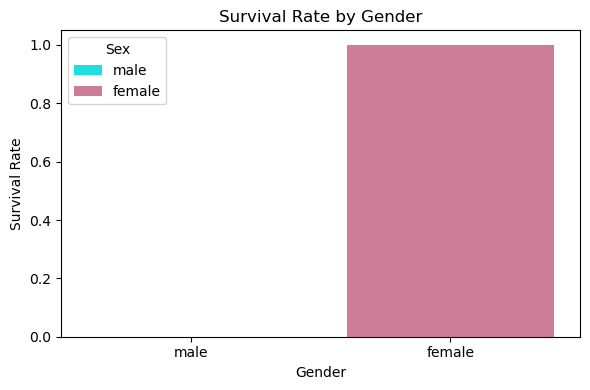

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df, errorbar=None, hue='Sex', palette={'female':'Palevioletred','male':'Cyan'}, legend=True)

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")
plt.tight_layout()
plt.savefig('Survival Rate by Gender', dpi=300, bbox_inches='tight')

plt.show()

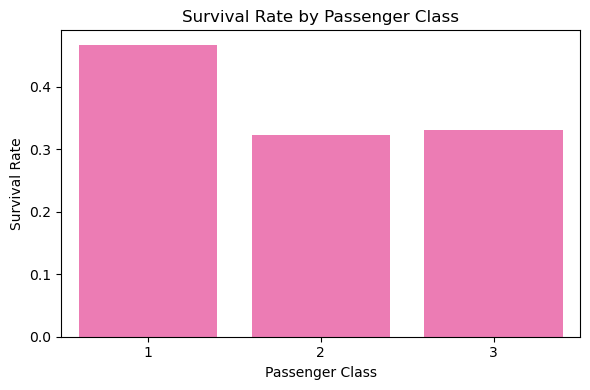

In [16]:
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df, errorbar=None , color='Hotpink')

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.tight_layout()
plt.savefig('Survival Rate by Passenger Class', dpi=300, bbox_inches='tight')

plt.show()

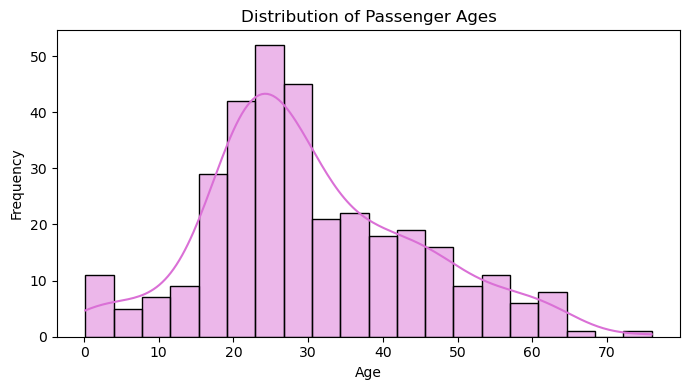

In [12]:
plt.figure(figsize=(7,4))
sns.histplot(df['Age'], bins=20, color='Orchid', kde=True)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig('Distribution of Passenger Ages', dpi=300, bbox_inches='tight')

plt.show()